## **Word2Vec (CBOW)**

Word2Vec is a family of algorithms introduced by _Mikolov et al._ in 2013 to learn dense vector representations of words from large text corpora. these vectors are called embeddings. These embeddings capture semantic relationships, such as similarity. There are two main architectures: **Continuous Bag-of-Words (CBOW)** and **Skip-gram**. In this notebook I'll focus on CBOW, which is efficient for frequent words and predicts a target(center) word given its surrounding context words. CBOW treats the context as a "bag" (unordered set) of words and aims to maximize the probability of the target word given that context. It's a shallow neural network with no hidden non-linearities beyond the embeddings, trained via backpropagation.



### Common Applications

* **Word similarity / semantic search:** Find synonyms, analogies
* **Text classification / sentiment analysis**
* **Named Entity Recognition (NER)**
* **Machine translation / multilingual embeddings**
* **Recommendation systems** (product or content embeddings)
* **Clustering / topic modeling** using vector similarities

### Python Implementation from Scratch

Below is a complete, self-contained Python implementation of **CBOW** using NumPy (no other ML libraries). It uses full softmax for simplicity, suitable for small corpora/vocabs. I've included comments for clarity. For large datasets, you'd need optimizations like **negative sampling** (I'll add a note on how to extend it). Throughout this notebook, I use the following corpus to test the code. Also I need to import pyhton modules and defineing some helper functions. After the topic is complete, the helper functions will be merged into the _CBOW_ class.

In [5]:
# Simple corpus
import numpy as np

corpus = """    
Mary Vance walked down the Valley with her head held high. She had on a new blue velvet cap with a scarlet rosette in it, a coat of navy blue
cloth and a little squirrel-fur muff. She was very conscious of her new clothes and very well pleased with herself. Her hair was elaborately
crimped, her face was quite plump, her cheeks rosy, her white eyes shining. She did not look much like the forlorn and ragged waif the
Merediths had found in the old Taylor barn. Una tried not to feel envious. Here was Mary with a new velvet cap, but she and Faith had to
wear their shabby old gray tams again this winter. Nobody ever thought of getting them new ones and they were afraid to ask their father for
them for fear that he might be short of money and then he would feel badly. Mary had told them once that ministers were always short of
money, and found it “awful hard” to make ends meet. Since then Faith and Una would have gone in rags rather than ask their father for
anything if they could help it. They did not worry a great deal over their shabbiness; but it was rather trying to see Mary Vance coming out
in such style and putting on such airs about it, too. The new squirrel muff was really the last straw. Neither Faith nor Una had ever had a
muff, counting themselves lucky if they could compass mittens without holes in them. Aunt Martha could not see to darn holes and though Una
tried to, she made sad cobbling. Somehow, they could not make their greeting of Mary very cordial. But Mary did not mind or notice that;
she was not overly sensitive. She vaulted lightly to a seat on the pine tree, and laid the offending muff on a bough. Una saw that it was lined
with shirred red satin and had red tassels. She looked down at her own rather purple, chapped, little hands and wondered if she would ever,
_ever_ be able to put them into a muff like that.
"""
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Numerical stability
    return exp_x / exp_x.sum(axis=0)

def get_context(self, context_idx):
        context = []
        for idx in context_idx:
            context.append(self.idx_to_word[idx])

        return context

### Step 1: Problem Setup and Notation
- **Corpus**: A sequence of words $w_1, w_2, \dots, w_T$, where $T$ is the total number of words.
- **Vocabulary**: A set of unique words $V = \{v_1, v_2, \dots, v_{|V|}\}$, with size $|V|$.
- **Center and Context words**: For a `center word`$^1$ $w_t$, the `context words`$^2$ is a window of $c$ words on each side, e.g., $[w_{t-c}, \dots, w_{t-1}, w_{t+1}, \dots, w_{t+c}]$. The context size is $2c$.
- **One-Hot Encoding**: Each word $w$ is represented as a one-hot vector $\mathbf{x} \in \mathbb{R}^{|V|}$, where $x_i = 1$ if $i$ corresponds to $w$, else 0.
- **Embeddings**: We learn two weight matrices:
  - Input embedding matrix $\mathbf{W}_{in} \in \mathbb{R}^{N \times |V|}$, where $N$ is the `embedding dimension`$^3$ (e.g., 100-300), this is a **hyperparameter**. The embedding for a word with one-hot $\mathbf{x}$ is $\mathbf{h} = \mathbf{W}_{in}.\mathbf{x} \in \mathbb{R}^N$. <br>If $\mathbf{x_i}=1$ then $\mathbf{W}_{in}.\mathbf{x}$ selects the column $i$ of matrix $\mathbf{W}_{in}$. thus $\mathbf{h}$ is the vector on column $\mathbf{i}$.
  
  - Output embedding matrix $\mathbf{W}_{out} \in \mathbb{R}^{|V| \times N}$, used to compute scores for the output layer.
- **Objective**: Maximize the average log probability over the corpus:
  $$J = \frac{1}{T} \sum_{t=1}^T \log P(w_t | w_{t-c}, \dots, w_{t-1}, w_{t+1}, \dots, w_{t+c})$$
  $P(w_t | w_{t-c}, \dots, w_{t-1}, w_{t+1}, \dots, w_{t+c})$ calculates the probability that $w_t$ is in the middle of $w_{t-c}, \dots,w_{t+c}$. this method predicts the probability of given word $w$ occurring in context of other words. Maximizing $J$ maximizes the probability over all words in the corpus.


In [6]:
from collections import Counter

class CBOW:
    def __init__(self, corpus, vocab_size=None, embedding_dim=100, window_size=2, learning_rate=0.025, epochs=5, min_count=5):
        self.corpus = corpus.lower().replace('.','').split()  # Simple tokenization for educational porpose.
        self.embedding_dim = embedding_dim    
        self.window_size = window_size        # used to slide window over center words
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.min_count = min_count            # Filter words by limited repeatation
        
        self.build_vocab(vocab_size)
        self.initialize_weights()
    
    def build_vocab(self, vocab_size=None):
        # Count word frequencies
        word_counts = Counter(self.corpus)
        # Filter words by min_count
        self.vocab = [word for word, count in word_counts.most_common(vocab_size) if count >= self.min_count]
        self.vocab_size = len(self.vocab)
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}

    def initialize_weights(self):
        '''
            Inintalize default input and output weights
        '''
        # Input embeddings: N x |V|
        self.W = np.random.uniform(low=-0.5 / self.embedding_dim, high= 0.5 / self.embedding_dim,size= (self.embedding_dim, self.vocab_size))
        # Output embeddings: |V| x N
        self.W_out = np.random.uniform(low=-0.5 / self.embedding_dim,high= 0.5 / self.embedding_dim,size= (self.vocab_size, self.embedding_dim))

        print('    Input embedding:',self.W.shape)
        print('   Output embedding:',self.W_out.shape)
        print('    Vocabulary size:',self.vocab_size)
        print('Embedding dimention:', self.embedding_dim)
    

    def generate_training_data(self):
        training_data = []
        for i in range(len(self.corpus)):
            word = self.corpus[i]
            # this eccures for filtered words(count < self.min_count is filtered in build_vocab)
            if word not in self.word_to_idx: continue

            # get index of selected word 
            target_idx = self.word_to_idx[word]
            context = []
            # generates 'context words'  
            for j in range(-self.window_size, self.window_size + 1):
                
                # J == 0 is equivalent to the center word
                if j == 0: continue

                if 0 <= i + j < len(self.corpus):
                    ctx_word = self.corpus[i + j]
                    if ctx_word in self.word_to_idx:
                        # append index to the 'context words' list
                        context.append(self.word_to_idx[ctx_word])
            # if context words is not empty ...
            if context: training_data.append((context, target_idx))
        # Each element contains a ([context word indices], center word index)
        return training_data
    
    def one_hot(self, idx): return np.eye(self.vocab_size)[idx]
    

### Code Explanation:
This step sets up the data structure and parameters, corresponding to defining the corpus, vocabulary, and embeddings in the mathematical formulation.
- **Initialization:** The `__init__` method sets hyperparameters (embedding dimension $N$, window size $c$, learning rate $\eta$, etc.) and preprocesses the corpus.
- **Vocabulary Building:** `build_vocab` counts word frequencies, filters out rare words (below `min_count`), and creates mappings between words and indices. This defines the vocabulary size $|V|$.
- **Weight Initialization:** `initialize_weights` creates the input embedding matrix $\mathbf{W}_{in}$ (shape $N \times |V|$) and output matrix $\mathbf{W}_{out}$ (shape $ |V| \times N $), initialized randomly with small values to avoid saturation.
- **One-Hot Encoding:** `one_hot` generates a _one-hot_ vector for a word index, used for the center word in training.


In the below, `CBOW class` has initalized to test the model. 

In [7]:
model = CBOW(corpus, embedding_dim=10, window_size=2, epochs=10, min_count=1)

    Input embedding: (10, 194)
   Output embedding: (194, 10)
    Vocabulary size: 194
Embedding dimention: 10


### Step 2: Forward Pass
In the Word2Vec model, the **forward pass** computes how likely a word is to appear in a given context, serving as the prediction step of the model. For CBOW, it estimates the probability of the center word given its surrounding context words, while for Skip-gram it estimates the probability of the surrounding context words given the center word. Mathematically, this is implemented through a softmax function that defines a conditional probability distribution over the vocabulary, where the similarity between word embeddings (inner products of input and output vectors) determines the likelihood of prediction. Thus, the forward pass has a clear **probabilistic interpretation**: it is equivalent to modeling conditional word probabilities in a language model.

In theory, Word2Vec defines the probability distribution, for example in CBOW: $P(w_t \mid w_{t-T}, \dots, w_{t-1}, w_{t+1}, \dots, w_{t+T})
$ using a softmax over the vocabulary. But in practice, directly computing this probability is _very expensive_ because the denominator of softmax requires summing over all words in the vocabulary (which can be millions). So instead of explicitly computing the probability, Word2Vec does the **forward pass step**: it projects the context words into embeddings, averages them, and then multiplies by the output weight matrix to get scores (logits). These scores are then used in an approximation method (e.g., **negative sampling** or **hierarchical softmax**) to update the embeddings without computing the full probability distribution. In short, theoretically Word2Vec models the probability distribution of words. but practically We compute the forward pass (vector operations) and approximate the probability using tricks like negative sampling.

**Forward Pass Network**: 
To calculate the loss function, we first compute the logit values, obtained by multiplying the output weight matrix $W_{out}$ with the hidden vector $h$. The hidden vector $h$ is the average of embeddings of one set of context words at a time, which are selected from the input embedding matrix $W_{in}. Initially, the values of both $W_{in}$ and $W_{out}$ are randomly initialized, typically using a uniform distribution. In the forward pass, we use these embeddings to form $h$, calculate the logits through $W_{out}h$, and then apply the loss function (such as cross-entropy) to optimize the model parameters.

The network has three layers: input (context), hidden (average embedding), and output (softmax).

1. **Input Layer**: For each context word $w_{t+j}$ (where $j \in [-c, c] \setminus \{0\}$), get its one-hot vector $h_{t+j}$ and $\mathbf{W}_{in}.h_{t+j}$ selects the embedding vector of word $w_{t+j}$. So, $\mathbf{h}$ is the average of embeding vectors of a set of context words for selected center word $t$.

2. **Hidden Layer**: Compute the average embedding of the context: $$\mathbf{h} = \frac{1}{2c} \sum_{j=-c, j \neq 0}^{c} \mathbf{W}_{in}.h_{t+j}$$
   This $\mathbf{h} \in \mathbb{R}^N$ is the average of the embeddings of context words that projects the context into the embedding space.

3. **Output Layer**: Compute unnormalized scores (logits) for all words in the vocabulary $\mathbf{u} = \mathbf{W}_{out} \mathbf{h} \in \mathbb{R}^{|V|}$ Then, apply softmax to get probabilities $P(w_t | \text{context}) =y_t= \frac{e^{u_t}}{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}}$
   where $t$ is the index of the center word.

In [8]:
# Since $x_{t+j}$ is a one-hot vector, w.xi extracts the weight vector of word i. Then its average weight is calculated. 
def forward(self, context_idxs):
    # Average context embeddings: h = (1/c) * sum(W[:, ctx] for ctx in context)
    h = np.zeros(self.embedding_dim)
    for ctx in context_idxs:
        # self.W[:, ctx] returns embeding vector of word ctx
        # em_vector: embedding vector
        em_vector = self.W[:,ctx]
        h += em_vector # W is N x |V|, so W[:, ctx] is embedding
    
    h /= len(context_idxs)  # Average
    
    # Logits u = W_out @ h
    u = self.W_out @ h
    
    # Softmax y
    y = softmax(u)
    # h: Average, u:Logits, y:Probability
    return h, u, y

### Code Explanation:
This step implements the forward propagation, mapping context words to a probability distribution over the vocabulary for the target word.
- **Hidden Layer:** The forward method takes a list of context word indices (`context_idxs`). For each context word, it retrieves the corresponding column from $\mathbf{W}_{in}$ (embedding vector) and computes the average to get $\mathbf{h}$.
- **Output Layer:** Computes `logits`$^4$ $\mathbf{u} = \mathbf{W}_{out} \mathbf{h}$ using matrix multiplication (NumPy’s @ operator).
- **Softmax:** The softmax method converts logits to probabilities, subtracting the maximum for numerical stability to prevent overflow in $e^{u_k}$.



### Review the some result

In [9]:
# build train data: Each element contains a ([context word indices], center word index)
data = model.generate_training_data()
# For example we print sixth item in the data
print(f'Center word: ({data[6][1]}, {model.idx_to_word[data[6][1]]})') # This prints 'center word'
print(f'The word indexed by {data[6][1]} has context words indexed by {data[6][0]}')

cwds = []
for idx in data[6][0]: cwds.append((idx,model.idx_to_word[idx]))

print(f'Context words are: {cwds}')
h, u, y = forward(model,data[6][0])

print(f'Size of h:{len(h)}. this is embedding dimention({model.embedding_dim})')
print(f'Size of u:{len(u)}. this is the vocabulary size({model.vocab_size})')
print(f'Size of h:{len(y)}. this is the vocabulary size({model.vocab_size})')

print(f'Sum of the logits is {sum(u)}')
print(f'Sum of the softmax is {sum(y)}')

Center word: (11, with)
The word indexed by 11 has context words indexed by [3, 56, 6, 57]
Context words are: [(3, 'the'), (56, 'valley'), (6, 'her'), (57, 'head')]
Size of h:10. this is embedding dimention(10)
Size of u:194. this is the vocabulary size(194)
Size of h:194. this is the vocabulary size(194)
Sum of the logits is -0.042159318999836395
Sum of the softmax is 1.0000000000000002


### Step 3: Loss Function
The goal of the loss function in CBOW is to maximize the probability of predicting the true target word given its context. In practice, the loss function (cross-entropy or negative log-likelihood) is minimized during training. Minimizing this loss is mathematically equivalent to maximizing the probability assigned to the correct word by the model. This encourages the model to learn word representations that make accurate predictions for the true words in their contexts. The predicted probability for the true center is $y_t$, and `we want this to be close to 1`. to obtain cross-entropy, we first compute $- \log P(w_t | \text{context})$ in the following:

$-\log \frac{e^{u_t}}{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}}=-(\log e^{u_t}-\log{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}})=-(u_t-\log{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}})=\boxed{-u_t+\log{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}}=E}$

> In practice, we minimize $E=-\log y_t$ instead of $y_t$ because $E$ penalizes low probabilities more strongly and is better suited for optimization. This helps the model learn to assign higher probability to the correct word. The main reason for using negative log likelihood (NLL) instead of just maximizing likelihood is not only to penalize low probabilities more strongly, but also because NLL provides a smooth, differentiable loss function suitable for gradient-based optimization. <br><br>NLL transforms the product of probabilities (maximum likelihood) into a sum via the logarithm, making optimization easier and numerically stable. It also ensures that the model is penalized more when it assigns low probability to the true word, which helps learning. So, both stronger penalization and optimization convenience are key reasons.

> Over a batch or the entire dataset, we average this loss where $\mathbf{u_t}$ is the **_logit_** of the given center word. The term $\mathbf{−u_t}$ penalizes the model if the logit of target word $\mathbf{u_t}$ is too small (we want it large). The $\mathbf{log\sum e^{u_k}}$ normalizes across all words in the vocabulary, ensuring a valid probability distribution. _So the loss is low when the target’s score $u_t$ is high relative to all other words’ scores_. This is exactly the negative log-likelihood of the correct word under the softmax distribution.

> In practice, for large $|V|$ e.g., 10,000+, computing the full softmax is expensive. The original Word2Vec uses approximations like _Negative Sampling_ or _Hierarchical Softmax_, but for this from-scratch implementation, we'll use full softmax for simplicity (assuming small vocabularies or toy examples).

In the following cell, we defined a simple loss function:

In [10]:
def compute_loss(u, target):
    # Loss E = -u_t + log(sum exp(u_k))
    return -u[target] + np.log(np.sum(np.exp(u)))

After forward pass can compute loss value of the model for each center word, It need to pass a context words array to return `h`, `logits` and `softmax` values. Using `generate_training_data`, the `model` has created well-structured train data, Now I can access to context words thruogh returned data. I access to context words at index `0` of each element and also to  center word at index `1`.

In [11]:
# I can access to context words thruogh returned data
data = model.generate_training_data()
idx = 10
context_words = data[idx][0]
center_word = data[idx][1]
print(f'Context word indices: {context_words}')
h, u, y = forward(model,context_words)

e = compute_loss(u, center_word)
print(f'This code tests loss of word "{center_word}:{model.idx_to_word[center_word]}".')
print(f'The value of Loss for word "{model.idx_to_word[center_word]}" is {e} (One iteration).')
print('This value need to update and minimize in the backpropagation step.')


Context word indices: [57, 58, 2, 7]
This code tests loss of word "59:high".
The value of Loss for word "high" is 5.267947743380587 (One iteration).
This value need to update and minimize in the backpropagation step.


### Code Explanation:
This step quantifies the error between predicted probabilities and the true target, driving the optimization.
- This function computes the cross-entropy loss for a single example.
- It takes the logits $ \mathbf{u} $ and the target word index target, computing $ -u_{\text{target}} + \log(\sum e^{u_k}) $.
- In the original code, this is part of the training loop (see below), but isolating it here clarifies the loss calculation step.


### Step 4: Backpropagation

In backpropagation, the goal is to update the input weight matrix $W_{\text{in}}$ and the output weight matrix $W_{\text{out}}$. These updates are performed using the `gradient descent`$^5$ method. After obtaining the logits in the forward pass, the function $f$ is the loss function $E$, which measures the difference between the predicted distribution and the true target word. Here $W_{in} \leftarrow W_{in} - \eta \frac{\partial E}{\partial W_{in}}$ and $W_{out} \leftarrow W_{out} - \eta \frac{\partial E}{\partial W_{out}}$. It is also noted that the softmax error term, $\frac{\partial E}{\partial u_k} = y_k - t_k$ and output error is $\mathbf{e = y-t}$ where $\mathbf{t}$ is the one-hot target ($t_t = 1$, others 0), and $\mathbf{y}$ is the softmax output.

**Update $\mathbf{W}_{out}$**: Since $u_k = \mathbf{W}_{out,k} \cdot \mathbf{h}$, the gradient for the row of $\mathbf{W}_{out}$ corresponding to word $k$ is: $\frac{\partial E}{\partial \mathbf{W}_{out,k}} = (y_k - t_k) \mathbf{h}^T$.

In matrix form: $\frac{\partial E}{\partial \mathbf{W}_{out}} = \mathbf{e}\,\mathbf{h}^T$ where $\mathbf{e} = \mathbf{y} - \mathbf{t}$. So, update rule is: $\boxed{\mathbf{W}_{out} \leftarrow \mathbf{W}_{out} - \eta \,\mathbf{e}\,\mathbf{h}^T}$.

**Update $\mathbf{W}_{in}$:** The error backpropagates obtains from using `chain rule` through the linear map $u=W_{out}.h$:

$$
\frac{\partial E}{\partial \mathbf{h}} =(\frac{\partial u}{\partial h})^T\frac{\partial E}{\partial \mathbf{u}}= \mathbf{W}_{out}^T \mathbf{e}
$$

This gives the signal that needs to be distributed to the input embeddings. Since $\mathbf{h}$ is the average of the context embeddings, then: $\mathbf{h} = \frac{1}{2c}\underset{j=-c, j\neq 0}{\overset{c}{\sum}} \mathbf{w}_{t+j}$ for each center word $w_t$. Each context word embedding contributes equally, so the gradient for each context embedding is: 

$\frac{\partial E}{\partial \mathbf{w}_{t+j}} =(\frac{\partial\mathbf{h}}{\partial{w_{tt+j}}})^T\frac{\partial E}{\partial \mathbf{h}}= \frac{1}{2c}\,\frac{\partial E}{\partial \mathbf{h}}= \frac{1}{2c}\mathbf{W}_{out}^T \mathbf{e}$.

So, update rule for each context word: $\boxed{\mathbf{w}_{t+j} \leftarrow \mathbf{w}_{t+j} - \eta \cdot \frac{1}{2c}\, \mathbf{W}_{out}^T \mathbf{e}}$.

In [12]:
# h: average of context words, y: softmax(logits)
def backward(self, context_idxs, target, h, y):
    # Error: e = y - t (t is one-hot target)
    t = self.one_hot(target)
    
    e = y - t
    # Update W_prime: W_prime -= lr * e.outer(h)
    dW_out = np.outer(e, h)
    self.W_out -= self.learning_rate * dW_out
    
    # Backprop to h: dh = W_prime.T @ e
    dh = self.W_out.T @ e
    
    # Update W for each context word
    for ctx in context_idxs:
        dW_ctx = (1.0 / len(context_idxs)) * dh
        self.W[:, ctx] -= self.learning_rate * dW_ctx

### Code Explanation:
This step computes and applies gradients to update the model parameters, aligning with the mathematical derivation. 
- This function (extracted from the `train` loop for clarity) handles backpropagation.
- **Output Weights:** Computes the error $ \mathbf{e} = \mathbf{y} - \mathbf{t} $, then updates $ \mathbf{W}_{out} $ using the gradient $ \mathbf{e} \mathbf{h}^T $ (via `np.outer`).
- **Hidden Layer Error:** Backpropagates the error to $ \mathbf{h} $: $ \frac{\partial E}{\partial \mathbf{h}} = {\mathbf{W}_{out}}^T \mathbf{e} $.
- **Input Weights:** Distributes the gradient to each context word’s embedding, scaled by $ \frac{1}{2c} $ (number of context words), updating the corresponding columns of $ \mathbf{W}_{in} $.


    Input embedding: (10, 194)
   Output embedding: (194, 10)
    Vocabulary size: 194
Embedding dimention: 10
This code tests loss of word "59:high".
Value of Loss for word "high" after 250 epochs is 4.156736981298647, (in real usage this is applied over all words in the vocabulary.)
The figure shows changes of 250 epochs for word "high".       
In the step 5 "train" function is implemented, In the following all codes is merged to obtain complete class of CBOW implementation.


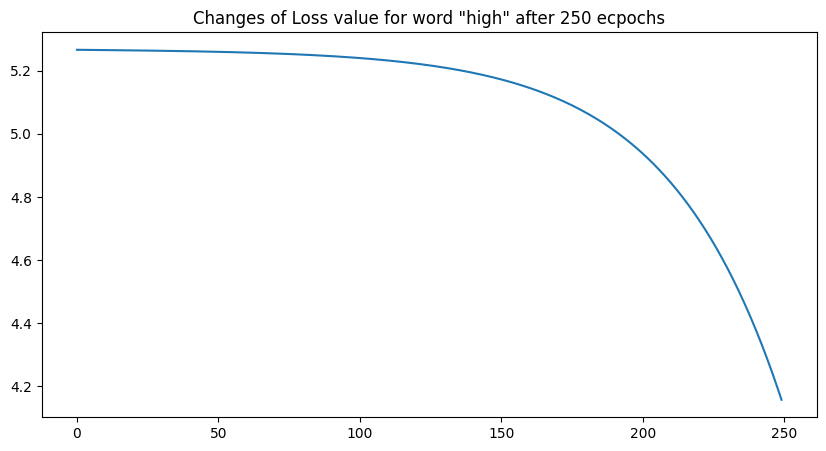

In [13]:
import matplotlib.pyplot as plt
model = CBOW(corpus, embedding_dim=10, window_size=2, epochs=10, min_count=1)
# I can access to context words thruogh returned data
data = model.generate_training_data()
idx = 10
context_words = data[idx][0]
center_word = data[idx][1]
loss = []
epochs = 250
e = 0
for epoch in range(epochs):
    # Returns h: average, z: logits, y: softmax(z)
    h, z, y = forward(model,context_words)
    # Compute loss of given 'center word'
    e = compute_loss(z, center_word)
    # Store errors 
    loss.append(e)
           
    # Backprop
    backward(model,context_words, center_word, h, y)

print(f'This code tests loss of word "{center_word}:{model.idx_to_word[center_word]}".')
print(f'Value of Loss for word "{model.idx_to_word[center_word]}" after {epochs} epochs is {e}, \
(in real usage this is applied over all words in the vocabulary.)')
print(f'The figure shows changes of {epochs} epochs for word "{model.idx_to_word[center_word]}". \
      \nIn the step 5 "train" function is implemented, In the following all codes is merged to obtain complete class of CBOW implementation.')
plt.figure(figsize=(10,5))
plt.title(f'Changes of Loss value for word "{model.idx_to_word[center_word]}" after {epochs} ecpochs')
plt.plot(loss)
plt.show()


### Step 5: Training
- **Initialization**: Initialize $\mathbf{W}_{in}$ and $\mathbf{W}_{out}$ randomly, e.g., uniform [-0.5/N, 0.5/N] to avoid saturation.
- **Subsampling and Negatives**: For efficiency, subsample frequent words and use negative sampling (sample negatives proportional to frequency^{0.75}).
- After training, the input embeddings $\mathbf{W}_{in}$ are typically used as the final word vectors.

This setup learns embeddings where similar words have close vectors (via dot product similarity).


In [14]:
            
def train(self, epochs=10,print_epochs=False):
    training_data = self.generate_training_data()
    loss = []
    print(f'             Epochs: {epochs}')
    print(f'       Running loop: {len(training_data)}x{epochs} = {len(training_data)*epochs}')
    print('Training ...')
    for epoch in range(epochs):
        total_loss = 0
    
        for context, target in training_data:
            # Returns h: average, z: logits, y: softmax(z)
            h, z, y = forward(self,context)
            
            # Compute loss of given 'center word'
            E = compute_loss(z, target)
            # updates total loss
            total_loss += E
            
            # Backprop
            backward(self,context, target, h, y)
        
        loss.append(total_loss)
        
        if print_epochs: print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(training_data):.4f}")
        
    print('Training ends.')
    return loss
    

### Code Explanation:
This step ties everything together, iterating over the dataset and optimizing the embeddings using the computed gradients.
- **Data Generation:** generate_training_data creates training pairs (context indices, target index) by sliding a window of size $ 2c $ over the corpus, skipping out-of-vocabulary words.
- **Training Loop:** The train method iterates over epochs, processing each training example:

    * Calls forward to get $ \mathbf{h} $, $ \mathbf{u} $, and $ \mathbf{y} $.
    * Computes the loss (via compute_loss, inlined in the original code).
    * Calls backward to update $ \mathbf{W}_{in} $ and $ \mathbf{W}_{out} $.
    * Reports the average loss per epoch.


- **Embedding Retrieval:** `get_embedding` extracts the learned embedding for a word from $ \mathbf{W}_{in} $.


    Input embedding: (10, 194)
   Output embedding: (194, 10)
    Vocabulary size: 194
Embedding dimention: 10
             Epochs: 250
       Running loop: 355x250 = 88750
Training ...
Training ends.


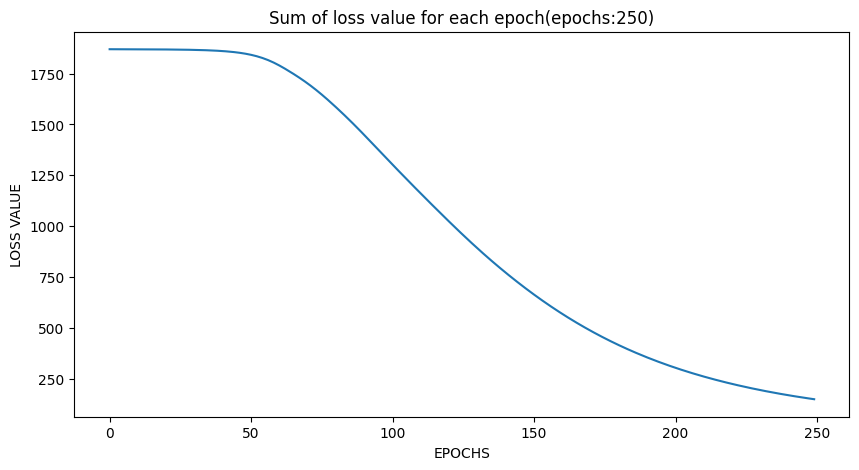

In [15]:
model = CBOW(corpus, embedding_dim=10, window_size=2, epochs=250, min_count=1)

loss = train(model,epochs=250)

plt.figure(figsize=(10,5))
plt.xlabel('EPOCHS')
plt.ylabel('LOSS VALUE')
plt.title(f'Sum of loss value for each epoch(epochs:{epochs})')
plt.plot(loss)
plt.show()

### Complete Code with Steps Integrated
Below is the complete code with the steps clearly separated, incorporating the isolated compute_loss and backward functions for clarity. It’s equivalent to the original but modularized to match the five steps.

In [16]:
import numpy as np
from collections import  Counter

class CBOW:
    # Step 1: Problem Setup
    def __init__(self, corpus, vocab_size=None, embedding_dim=100, window_size=2, learning_rate=0.025, epochs=5, min_count=5):
        self.corpus = corpus.lower().split()
        self.embedding_dim = embedding_dim
        self.window_size = window_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.min_count = min_count
        self.build_vocab(vocab_size)
        self.initialize_weights()
    
    def build_vocab(self, vocab_size=None):
        word_counts = Counter(self.corpus)
        self.vocab = [word for word, count in word_counts.most_common(vocab_size) if count >= self.min_count]
        self.vocab_size = len(self.vocab)
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}
        print(f"Vocabulary size: {self.vocab_size}")
    
    def initialize_weights(self):
        self.W = np.random.uniform(-0.5 / self.embedding_dim, 0.5 / self.embedding_dim, (self.embedding_dim, self.vocab_size))
        self.W_out = np.random.uniform(-0.5 / self.embedding_dim, 0.5 / self.embedding_dim, (self.vocab_size, self.embedding_dim))
    
    def one_hot(self, idx):
        return np.eye(self.vocab_size)[idx]
    
    # Step 2: Forward Pass
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x))
        return exp_x / exp_x.sum(axis=0)
    
    def forward(self, context_idxs):
        h = np.zeros(self.embedding_dim)
        for ctx in context_idxs:
            h += self.W[:, ctx]
        h /= len(context_idxs)
        u = self.W_out @ h
        y = self.softmax(u)
        return h, u, y
    
    # Step 3: Loss Function
    def compute_loss(self, u, target):
        return -u[target] + np.log(np.sum(np.exp(u)))
    
    # Step 4: Backpropagation and Gradients
    def backward(self, context_idxs, target, h, y):
        t = self.one_hot(target)
        e = y - t
        dW_prime = np.outer(e, h)
        self.W_out -= self.learning_rate * dW_prime
        dh = self.W_out.T @ e
        for ctx in context_idxs:
            dW_ctx = (1.0 / len(context_idxs)) * dh
            self.W[:, ctx] -= self.learning_rate * dW_ctx
    
    # Step 5: Training and Hyperparameters
    def generate_training_data(self):
        training_data = []
        for i in range(len(self.corpus)):
            word = self.corpus[i]
            if word not in self.word_to_idx:
                continue
            target_idx = self.word_to_idx[word]
            context = []
            for j in range(-self.window_size, self.window_size + 1):
                if j == 0:
                    continue
                if 0 <= i + j < len(self.corpus):
                    ctx_word = self.corpus[i + j]
                    if ctx_word in self.word_to_idx:
                        context.append(self.word_to_idx[ctx_word])
            if context:
                training_data.append((context, target_idx))
        return training_data
    
    def train(self, show_epoch = False):
        training_data = self.generate_training_data()
        for epoch in range(self.epochs):
            total_loss = 0
            for context, target in training_data:
                h, u, y = self.forward(context)
                E = self.compute_loss(u, target)
                total_loss += E
                self.backward(context, target, h, y)
            if show_epoch:
                print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {total_loss / len(training_data):.4f}")
    
    def get_embedding(self, word):
        if word in self.word_to_idx:
            return self.W[:, self.word_to_idx[word]]
        return None

### Example usage

In [17]:
# Example usage
#corpus = "We are about to study the idea of a computational process. Computational processes are abstract beings that inhabit computers. As they evolve, processes manipulate other abstract things called data. The evolution of a process is directed by a pattern of rules called a program. People create programs to direct processes. In effect, we conjure the spirits of the computer with our spells."
model = CBOW(corpus, embedding_dim=10, window_size=2, epochs=100, min_count=1)
model.train()
word = model.idx_to_word[59]
print(f"Embedding for word '{word}':\n", model.get_embedding(word))

Vocabulary size: 198
Embedding for word 'high.':
 [-0.02211377 -0.1244763  -0.07816577 -0.19404477  0.45121571 -0.11404804
  0.3631981  -0.53565638  0.0780683  -0.03749935]


This breakdown makes the implementation modular and directly traceable to the mathematical steps, aiding understanding. For large-scale use, consider adding negative sampling or hierarchical softmax to reduce computational cost, as noted in the original explanation. You can run this code with a small corpus as shown, and it will produce embeddings for each word in the vocabulary. the embedding vectors are available by **get_embedding(word)** for each word in the vocabulary.

---

## **Negative Sampling**
Negative Sampling is an optimization technique used in training models like Word2Vec (including CBOW and Skip-gram) to make the learning process more computationally efficient, especially for large vocabularies. Below, We will explain negative sampling in the context of CBOW model, focusing on its purpose and mathematical foundation.


To update the CBOW implementation with negative sampling, we need to modify the `loss function` and `gradient computation` to make training more efficient. Negative sampling avoids computing the full softmax by approximating the loss using the target word and a small number of randomly sampled "negative" words. Below, we’ll explain the changes in the context of the mathematical background and provide the updated code, keeping the same five-step structure from the previous steps. The changes primarily affect `Step 3` (Loss Function) and `Step 4` (Backpropagation), with minor adjustments elsewhere to support negative sampling.

### Mathematical Background
In the original CBOW implementation, we used the full softmax loss, $E$, This requires computing $e^{u_k}$ for all words in the vocabulary $V$, which is computationally expensive for large vocabularies (e.g., $|V| > 10,000$). Negative Sampling approximates the loss by considering only the target word (positive example) and $K$ randomly sampled negative words (typically $K = 5-20 $). Negative words are sampled from a noise distribution, often the unigram distribution raised to the power of 0.75: $P(w) \propto \text{freq}(w)^{0.75}$. The loss becomes:
 $$E = -\log \sigma(u_t) - \overset{K}{\underset{k=1}{\sum}} \log \sigma(-u_k)$$

represents the `error` or `negative log-likelihood` that the model is trying to minimize. A lower value of $E$ indicates a better prediction by the model.
* **$u_t$** represents the dot product between the learned context vector (the average of the input vectors in the CBOW window) and the output vector of the true target word $w_t$. In essence, it's a measure of the similarity or compatibility between the context and the target word.

* **$\sigma(x)$** is the `Sigmoid function`, defined as $\sigma(x) = \frac{1}{1 + e^{-x}}$. It squashes the input $x$ (in this case, $u_t$) into a probability-like value between `0` and `1`. The sigmoid function here represents the model's predicted probability that $w_t$ is a `positive (target) word` given the context.

* **$\log \sigma(u_t)$**: This is the `log-probability` of the true target word. Since $\sigma(u_t)$ is between `0` and `1`, $\log \sigma(u_t)$ will be a `negative` number (e.g., $\log(0.9) \approx -0.105$).

* **$-\log \sigma(u_t)$**: This is the `negative log-probability`. Because the model is trying to maximize $\sigma(u_t)$ (i.e., maximize the predicted probability of the target word), minimizing the negative log-probability achieves this goal. If $\sigma(u_t)$ is close to 1, $-\log \sigma(u_t)$ is close to 0 (low loss).

* **$k=1$ to $K$**: represents the summation over $K$ `randomly` selected words that are `not` the target word $w_t$. These are the `negative samples`.


* **$u_k$**: This is the dot product between the learned context vector and the output vector of the $k^{th}$ `negative sample` $w_k$.

* **$\sigma(-u_k)$**: Since we want the model to predict that the negative sample $w_k$ is **not** the target word, we look at the probability $\sigma(-u_k)$.
    * Recall that $\sigma(-x) = 1 - \sigma(x)$. Therefore, $\sigma(-u_k)$ represents $1 - \sigma(u_k)$, which is the model's predicted probability that $w_k$ is a _`negative`_` (non-target) word` given the context.

* **$\log \sigma(-u_k)$** is the `log-probability` that the $k^{th}$ negative word is a `negative sample`. The model wants this probability to be high (close to 1).

* **$-\overset{K}{\underset{k=1}{\sum}} \log \sigma(-u_k)$** is the sum of the negative log-probabilities of all negative samples. By `minimizing` this term, the model is forced to `maximize` the log-probability of each $\sigma(-u_k)$, thereby pushing the probability that each random word is a negative sample `closer to 1`.

> Negative Sampling reduces the computational cost from $\mathcal{O}(|V|)$ to $\mathcal{O}(K + 1)$ per training example. and the gradients only update the weights for the target word and the $K$ negative words, not the entire $\mathbf{W}_{out}$.<br><br>In essence, the negative sampling loss function transforms the large, computationally expensive task of classifying the target word out of the entire vocabulary into a series of $K+1$ `independent binary classification tasks`:<br><br>1.  `One positive task`, Is the target word $w_t$ the correct word? (We want the prediction $\sigma(u_t) \approx 1$).<br>2.  `K negative tasks`, Are the randomly sampled words $w_k$ the correct word? (We want the predictions $\sigma(u_k) \approx 0$, which is achieved by maximizing $\sigma(-u_k)$ to $\approx 1$).<br><br>The overall goal is to find word vectors such that the dot product with the context vector is `large and positive` for the true target word ($u_t \to \infty$) and `large and negative` for all the sampled negative words ($u_k \to -\infty$).

**Gradient Updates**:
- For the target word $t$:$\frac{\partial E}{\partial u_t} = \sigma(u_t) - 1$

  Update $\mathbf{W}_t \leftarrow \mathbf{W}_t - \eta (\sigma(u_t) - 1) \mathbf{h}$.
- For a negative word $k$: $\frac{\partial E}{\partial u_k} = \sigma(u_k)$

  Update $\mathbf{W}_k \leftarrow \mathbf{W}_k - \eta \sigma(u_k) \mathbf{h}$.
- The error backpropagated to the hidden layer is: $\frac{\partial E}{\partial \mathbf{h}} = (\sigma(u_t) - 1) \mathbf{W}_t + \overset{K}{\underset{k=1}{\sum}} \sigma(u_k) \mathbf{W}_k$

- The input embeddings $\mathbf{W}_{in}$ are updated as before, distributing $\frac{\partial E}{\partial \mathbf{h}}$ to each context word.

**Sampling Negative Words**:
- We sample negatives from $P(w) \propto \text{freq}(w)^{0.75}$, which gives more weight to frequent words but less than their raw frequency, balancing informativeness.

### Updated Code with Negative Sampling
The code retains the five-step structure, with changes in **Step 3 (Loss Function)** and **Step 4 (Backpropagation)** to implement negative sampling. Additionally, we modify **Step 1 (Problem Setup)** to compute the unigram distribution for sampling negatives. The forward pass and training loop are adjusted slightly to accommodate the new loss and gradient updates.

In [60]:
import numpy as np
from collections import Counter
import random

class CBOW:
    # Step 1: Problem Setup (Updated for Negative Sampling)
    def __init__(self, corpus, vocab_size=None, embedding_dim=100, window_size=2, learning_rate=0.025, epochs=5, min_count=5, neg_samples=5):
        self.corpus = corpus.lower().split()
        self.embedding_dim = embedding_dim
        self.window_size = window_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.min_count = min_count
        self.neg_samples = neg_samples  # Number of negative samples
        self.build_vocab(vocab_size)
        self.initialize_weights()
        self.build_unigram_table()
    
    def build_vocab(self, vocab_size=None):
        word_counts = Counter(self.corpus)
        self.vocab = [word for word, count in word_counts.most_common(vocab_size) if count >= self.min_count]
        self.vocab_size = len(self.vocab)
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}
        # Store word frequencies for negative sampling
        self.word_freqs = np.array([word_counts[word] for word in self.vocab], dtype=float)
        self.word_freqs = self.word_freqs ** 0.75  # Unigram^0.75
        self.word_freqs /= self.word_freqs.sum()  # Normalize to probabilities
        print(f"Vocabulary size: {self.vocab_size}")
    
    def build_unigram_table(self):
        # Create a table for efficient negative sampling
        table_size = 1_000_000
        self.unigram_table = []
        for idx in range(self.vocab_size):
            count = int(self.word_freqs[idx] * table_size)
            self.unigram_table.extend([idx] * count)
    
    def initialize_weights(self):
        self.W = np.random.uniform(-0.5 / self.embedding_dim, 0.5 / self.embedding_dim, (self.embedding_dim, self.vocab_size))
        self.W_out = np.random.uniform(-0.5 / self.embedding_dim, 0.5 / self.embedding_dim, (self.vocab_size, self.embedding_dim))
    
    def one_hot(self, idx):
        return np.eye(self.vocab_size)[idx]
    
    # Step 2: Forward Pass (Adjusted for Negative Sampling)
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def forward(self, context_idxs):
        h = np.zeros(self.embedding_dim)
        for ctx in context_idxs:
            h += self.W[:, ctx]
        h /= len(context_idxs)
        return h
    
    # Step 3: Loss Function (Negative Sampling)
    def compute_loss(self, h, target, neg_samples):
        # Positive sample
        u_pos = np.dot(self.W_out[target], h)
        loss = -np.log(self.sigmoid(u_pos))
        
        # Negative samples
        for neg_idx in neg_samples:
            u_neg = np.dot(self.W_out[neg_idx], h)
            loss -= np.log(self.sigmoid(-u_neg))
        
        return loss
    
    # Step 4: Backpropagation and Gradients (Negative Sampling)
    def backward(self, context_idxs, target, h, neg_samples):
        # Gradient for positive sample
        u_pos = np.dot(self.W_out[target], h)
        grad_pos = self.sigmoid(u_pos) - 1
        dh = grad_pos * self.W_out[target]
        self.W_out[target] -= self.learning_rate * grad_pos * h
        
        # Gradients for negative samples
        for neg_idx in neg_samples:
            u_neg = np.dot(self.W_out[neg_idx], h)
            grad_neg = self.sigmoid(u_neg)
            dh += grad_neg * self.W_out[neg_idx]
            self.W_out[neg_idx] -= self.learning_rate * grad_neg * h
        
        # Update input embeddings
        for ctx in context_idxs:
            dW_ctx = (1.0 / len(context_idxs)) * dh
            self.W[:, ctx] -= self.learning_rate * dW_ctx
    
    # Step 5: Training and Hyperparameters
    def generate_training_data(self):
        training_data = []
        for i in range(len(self.corpus)):
            word = self.corpus[i]
            if word not in self.word_to_idx:
                continue
            target_idx = self.word_to_idx[word]
            context = []
            for j in range(-self.window_size, self.window_size + 1):
                if j == 0:
                    continue
                if 0 <= i + j < len(self.corpus):
                    ctx_word = self.corpus[i + j]
                    if ctx_word in self.word_to_idx:
                        context.append(self.word_to_idx[ctx_word])
            if context:
                training_data.append((context, target_idx))
        return training_data
    
    def sample_negatives(self, target):
        # Sample K negative words, excluding the target
        negatives = []
        while len(negatives) < self.neg_samples:
            idx = random.choice(self.unigram_table)
            
            if idx != target: negatives.append(idx)
        
        return negatives
    
    def train(self):
        training_data = self.generate_training_data()
        for epoch in range(self.epochs):
            total_loss = 0
            for context, target in training_data:
                h = self.forward(context)
                neg_samples = self.sample_negatives(target)
                E = self.compute_loss(h, target, neg_samples)
                total_loss += E
                self.backward(context, target, h, neg_samples)
            print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {total_loss / len(training_data):.4f}")
    
    def get_embedding(self, word):
        if word in self.word_to_idx:
            return self.W[:, self.word_to_idx[word]]
        return None

In [ ]:
# Example usage
corpus = "We are about to study the idea of a computational process. Computational processes are abstract beings that inhabit computers. As they evolve, processes manipulate other abstract things called data. The evolution of a process is directed by a pattern of rules called a program. People create programs to direct processes. In effect, we conjure the spirits of the computer with our spells."
model = CBOW(corpus, embedding_dim=10, window_size=2, epochs=10, min_count=1, neg_samples=5)
model.train()
print("Embedding for 'process':", model.get_embedding('process'))

In [59]:
print(max(model.unigram_table))
print(sum(model.unigram_table))
print(len(model.unigram_table))

45
1089
65


### **Foot Notes**

1- **Center word**: The center word is the target word we are currently trying to represent or predict in Word2Vec, In Skip-Gram we start from the center word and try to predict its surrounding words. In CBOW we predict the center word based on its surrounding words. Imagine reading a sentence. At each step, the word you are “focusing on” is the center word. for example in sentence "_The quick brown fox jumps over the lazy dog_", If the center word is "_fox_", we focus on "_fox_" in that step.

2- **Context words**: Context words are the words surrounding the center word within a fixed “window” size. They provide semantic context for learning the representation of the center word. The window size determines how many words on the left and right are considered. in the mentioned sentence if we set window size to `2`, for center word _fox_  context words (2 on each side) are "quick", "brown", "jumps", "over". So for this step:

Center word= "fox" then Context words=["quick","brown","jumps","over"] 

3- **Embedding dimention**: The embedding dimension refers to the _number of dimensions (or features)_ in the dense vector used to represent each word. In simpler terms, it's the length of the vector that a word is converted into. For example, if you set the embedding dimension to 100, every word in your vocabulary will be represented by a vector of 100 numbers.

In fact, think of the embedding dimension as a set of axes in a high-dimensional space, says how many features (dimensions) should be generated for each word. This represents each word as a point in vector space. The model learns to place similar words close to each other and this dimension determines the "size" of this space. 

If the dimension is too small (e.g., 2), the model can't capture all the complex semantic relationships between words. It's like trying to represent a detailed map of the world on a single, flat line. In the other hand a larger dimension (e.g., 300) allows the model to capture more nuanced meanings and relationships. However, if it's too large, it can lead to **overfitting**, where the model memorizes the training data but fails to generalize to new data. It also increases computational cost.

The values in a word's vector are not random; they are learned during the training of models like Word2Vec. The model adjusts the values based on a word's context. Words that appear in similar contexts (e.g., "book" and "notebook") will have their vectors adjusted in similar ways, resulting in their final vectors being close to each other in the high-dimensional space. The embedding dimension dictates how many numbers are used to encode this contextual information.

### Optimal Embedding Dimension

There is no one-size-fits-all value for the embedding dimension. The optimal value depends on several factors:

1.  **Corpus Size:** For a larger corpus with a rich vocabulary, a higher embedding dimension (e.g., 200-300) is often better to capture the vast number of relationships.
2.  **Task Complexity:** More complex tasks like machine translation might require a higher dimension than a simpler task like sentiment analysis.
3.  **Computational Resources:** A higher dimension requires more memory and processing power.

Commonly used embedding dimensions range from **50 to 300**, with 100 or 200 being typical starting points for many NLP tasks.

4- **Logits**: In machine learning, logits are the raw, unnormalized scores produced by a model before applying a normalization function like the softmax or sigmoid. They represent the direct outputs of the linear transformation (e.g., $u_k = \mathbf{v}_k^\top \mathbf{h}$ in Word2Vec), and can take any real value, positive or negative. Since logits are not constrained to sum to one or fall within a fixed range, they are easier for the model to optimize during training. A softmax function then converts these logits into a probability distribution over classes, while a sigmoid squashes them into probabilities for binary outcomes. Thus, logits can be thought of as the “evidence” or “score” for each class before being translated into interpretable probabilities.

5- **Gradient descent**:  In gradient descent, the parameters $\theta$ are updated according to the rule $\theta \leftarrow \theta - \eta \,\frac{\partial f}{\partial \theta},$ where $f$ is the objective function and $\eta$ is the learning rate.

### Most relevant Citations

1. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv preprint arXiv:1301.3781*. https://arxiv.org/abs/1301.3781
   - **Description**: This paper introduces the Word2Vec framework, including the Continuous Bag-of-Words (CBOW) model and the negative sampling technique, which are central to the implementation discussed.
   - **Relevance**: Cited in the context of "Word2Vec, introduced by Mikolov et al. (2013)" for the CBOW architecture and negative sampling optimization.

2. Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. *Advances in Neural Information Processing Systems, 26*, 3111–3119. https://papers.nips.cc/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf
   - **Description**: This follow-up paper elaborates on Word2Vec, detailing negative sampling and the unigram distribution raised to the power of 0.75 for sampling negative words.
   - **Relevance**: Provides additional context for the negative sampling implementation and hyperparameter choices (e.g., the 0.75 exponent).

3. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
   - **Description**: This paper introduces scikit-learn, the library used to access the 20 Newsgroups dataset via the `fetch_20newsgroups` function.
   - **Relevance**: The 20 Newsgroups dataset, originally collected by Ken Lang, is provided through scikit-learn, used as the real-world corpus for training the CBOW model.

## Please give me a star ⭐ on Github if this topic was helpful to you.